In [1]:
from pathlib import Path
from textwrap import wrap

import cartopy.crs as ccrs
import earthaccess
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr

plt.style.use("seaborn-v0_8-notebook")

In [2]:
auth = earthaccess.login()
results = earthaccess.search_datasets(instrument="harp2")

for item in results:
    summary = item.summary()
    print(summary["short-name"])


PACE_HARP2_L1C_SCI
PACE_HARP2_L2_MAPOL_OCEAN_NRT
PACE_HARP2_L2_CLOUD_GPC
PACE_HARP2_L2_CLOUD_GPC_NRT
PACE_HARP2_L2_MAPOL_OCEAN
PACE_HARP2_L3M_CLOUD_GPC
PACE_HARP2_L0_D1
PACE_HARP2_L0_D2
PACE_HARP2_L0_D3
PACE_HARP2_L1A_SCI
PACE_HARP2_L1B_SCI
PACE_HARP2_L3M_CLOUD_GPC_NRT
PACE_HARP2_L3M_MAPOL_OCEAN
PACE_HARP2_L3M_MAPOL_OCEAN_NRT


In [3]:
tspan = ("2025-07-10", "2025-07-10")
bbox = (-170, -60, -120, -50) #west, south, east, north corners
bbox = (-90, -15, -89, -14) #example from hackweek



#tspan = ("2025-07-05", "2025-07-05")
#bbox = (-130, 30, -120, 40) #western california

L1B_results = earthaccess.search_data(
    short_name="PACE_HARP2_L1B_SCI",
    temporal=tspan,
    bounding_box=bbox,  # (west, south, east, north) if desired
    count=1,
)
L1B_paths = earthaccess.open(L1B_results)

L1C_results = earthaccess.search_data(
    short_name="PACE_HARP2_L1C_SCI",
    temporal=tspan,
    bounding_box=bbox,  # (west, south, east, north) if desired
    count=1,
)
L1C_paths = earthaccess.open(L1C_results)

L2_results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC_NRT",
    temporal=tspan,
    bounding_box=bbox,  # (west, south, east, north) if desired
    count=1,
)
L2_paths = earthaccess.open(L2_results)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
L1B_datatree = xr.open_datatree(L1B_paths[0])
L1B_dataset = xr.merge(L1B_datatree.to_dict().values())
L1C_datatree = xr.open_datatree(L1C_paths[0])
L1C_dataset = xr.merge(L1C_datatree.to_dict().values())
L2_datatree = xr.open_datatree(L2_paths[0])
L2_dataset = xr.merge(L2_datatree.to_dict().values())

/tmp/ipykernel_139/1391546596.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  L1C_datatree = xr.open_datatree(L1C_paths[0])


In [5]:
#L1C_datatree
L2_datatree
#L1C_paths

<xarray.DataTree>
Group: /
│   Attributes: (12/110)
│       Conventions:                                            CF-1.10
│       acquisition_scheme:                                     4
│       att_pitch_start_end_degrees:                            [-0.13411392 -0.1...
│       att_roll_start_end_degrees:                             [-0.2059145  -0.2...
│       att_time_offset:                                        0.0
│       att_yaw_start_end_degrees:                              [-12.857903 -12.1...
│       ...                                                     ...
│       cloud_rft_lut_file_name:                                /sdps/sdpsoper/Sc...
│       cloud_rft_scatt_angle_required_min:                     135.83791174582538
│       cloud_rft_scatt_angle_required_max:                     150.0
│       cloud_rft_scatt_angle_to_use_lo:                        135.83791174582538
│       cloud_rft_scatt_angle_to_use_hi:                        165.0
│       cloud_rft_decomposition_size_correlation_required_min:  0.95
├── Group: /bin_attributes
│       Dimensions:          (bins_along_track: 395)
│       Dimensions without coordinates: bins_along_track
│       Data variables:
│           nadir_view_time  (bins_along_track) float64 3kB ...
├── Group: /geolocation_data
│       Dimensions:    (bins_along_track: 395, bins_across_track: 519)
│       Dimensions without coordinates: bins_along_track, bins_across_track
│       Data variables:
│           latitude   (bins_along_track, bins_across_track) float32 820kB ...
│           longitude  (bins_along_track, bins_across_track) float32 820kB ...
└── Group: /geophysical_data
        Dimensions:                                           (bins_along_track: 395,
                                                               bins_across_track: 519,
                                                               dim_cloud_bow_retrieval_params: 3)
        Dimensions without coordinates: bins_along_track, bins_across_track,
                                        dim_cloud_bow_retrieval_params
        Data variables: (12/29)
            cloud_top_altitude                                (bins_along_track, bins_across_track) float32 820kB ...
            cloud_top_temperature                             (bins_along_track, bins_across_track) float32 820kB ...
            cloud_top_pressure                                (bins_along_track, bins_across_track) float32 820kB ...
            cloud_liquid_index                                (bins_along_track, bins_across_track) float32 820kB ...
            cloud_bow_droplet_effective_radius                (bins_along_track, bins_across_track) float32 820kB ...
            cloud_bow_droplet_effective_radius_stddev         (bins_along_track, bins_across_track) float32 820kB ...
            ...                                                ...
            cloud_bow_lidar_ratio_532nm                       (bins_along_track, bins_across_track) float32 820kB ...
            cloud_bow_droplet_number_concentration_adiabatic  (bins_along_track, bins_across_track) float32 820kB ...
            cloud_bow_liquid_water_path                       (bins_along_track, bins_across_track) float32 820kB ...
            cloud_quality                                     (bins_along_track, bins_across_track) float32 820kB ...
            cloud_bow_quality_retrieval_fail                  (bins_along_track, bins_across_track) float32 820kB ...
            cloud_rft_quality_retrieval_fail                  (bins_along_track, bins_across_track) float32 820kB ...

In [19]:
transform = ccrs.PlateCarree(central_longitude=0)
projection = ccrs.PlateCarree()


def extremes_removed_ids(x):
    """
    Returns indices of array x after removing the extreme values
    """
    q3 = np.percentile(x, 95)
    q1 = np.percentile(x, 5)
    xmin = q1 - 1.5 * (q3 - q1)
    xmax = q3 + 1.5 * (q3 - q1)
    return (xmin <= x) * (x < xmax)


def geo_axis_tags(ax, crs=ccrs.PlateCarree(central_longitude=0)):
    gl = ax.gridlines(crs=crs, draw_labels=True)
    ax.coastlines()
    # gl = ax.gridlines(draw_labels=True,linestyle='--',\
    #     xlocs=mticker.FixedLocator(np.arange(-180,180.1,10)),ylocs=mticker.FixedLocator(np.arange(-90,90.1,10)))
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12, "color": "k"}
    gl.ylabel_style = {"size": 12, "color": "k"}

    ax.coastlines()
    return gl

In [20]:
var = "cloud_liquid_index"
print(L2_dataset[var].shape)
var = "rotation_angle"
print(L1C_dataset[var].shape)
L1C_dataset[var]

print(L2_dataset["cloud_liquid_index"])

(395, 519)
(395, 519, 90)
<xarray.DataArray 'cloud_liquid_index' (bins_along_track: 395,
                                        bins_across_track: 519)> Size: 820kB
[205005 values with dtype=float32]
Dimensions without coordinates: bins_along_track, bins_across_track
Attributes:
    long_name:  Index indicating the strength of the primary rainbow in the o...
    units:      1
    valid_min:  -10.0
    valid_max:  10.0


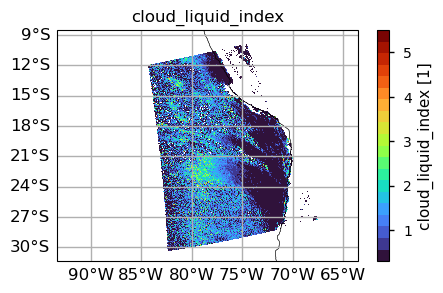

In [21]:
### START WITH L2
var = "cloud_liquid_index"
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
_arr = L2_dataset[var].values
arr_tes = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].min(),
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L2_dataset.longitude,
    L2_dataset.latitude,
    arr_tes,
    transform=transform,
    cmap=cmap,
    vmin=0.3,
    vmax=vmax,
)
ax1.set_title(var, size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % (var, L2_dataset[var].units)
)

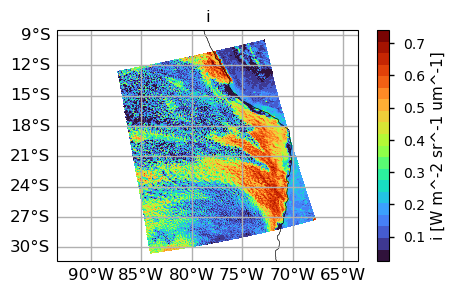

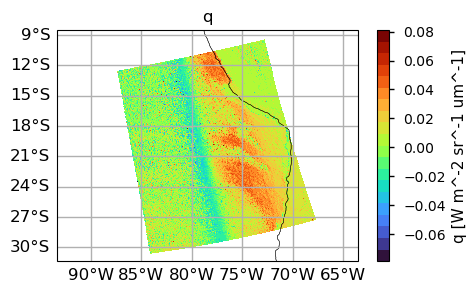

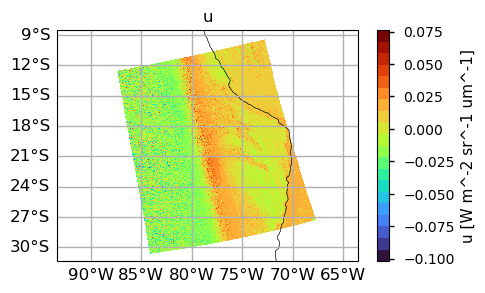

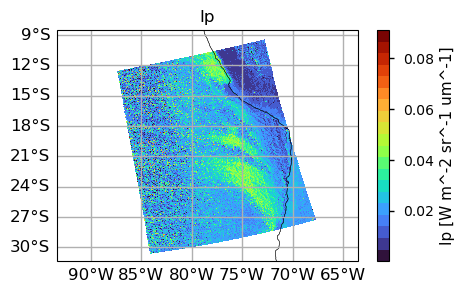

In [22]:
## PROCEED TO L1C
var = "i"
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
iang=35
_arr = (np.pi*L1C_dataset[var].values[:,:,iang].squeeze())/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"].values[:,:,iang].squeeze()))) #np.sqrt(L1C_dataset[var].values[:,:,iang].squeeze()**2+L1C_dataset["u"].values[:,:,iang].squeeze()**2)
arr_tes = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].min(),
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L1C_dataset.longitude,
    L1C_dataset.latitude,
    arr_tes,
    transform=transform,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title(var, size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % (var, L1C_dataset[var].units)
)

var = "q"
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
_arr = (np.pi*L1C_dataset[var].values[:,:,iang].squeeze())/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"].values[:,:,iang].squeeze()))) #np.sqrt(L1C_dataset[var].values[:,:,iang].squeeze()**2+L1C_dataset["u"].values[:,:,iang].squeeze()**2)
q_sv = _arr
arr_tes = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].min(),
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L1C_dataset.longitude,
    L1C_dataset.latitude,
    arr_tes,
    transform=transform,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title(var, size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % (var, L1C_dataset[var].units)
)

var = "u"
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
_arr = (np.pi*L1C_dataset[var].values[:,:,iang].squeeze())/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"].values[:,:,iang].squeeze()))) #np.sqrt(L1C_dataset[var].values[:,:,iang].squeeze()**2+L1C_dataset["u"].values[:,:,iang].squeeze()**2)
u_sv = _arr
arr_tes = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].min(),
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L1C_dataset.longitude,
    L1C_dataset.latitude,
    arr_tes,
    transform=transform,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title(var, size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % (var, L1C_dataset[var].units)
)

var = "Ip"
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
_arr = np.sqrt(q_sv**2+u_sv**2)
arr_tes = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].min(),
    arr_tes.compressed()[extremes_removed_ids(arr_tes.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L1C_dataset.longitude,
    L1C_dataset.latitude,
    arr_tes,
    transform=transform,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title(var, size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % (var, L1C_dataset["q"].units)
)

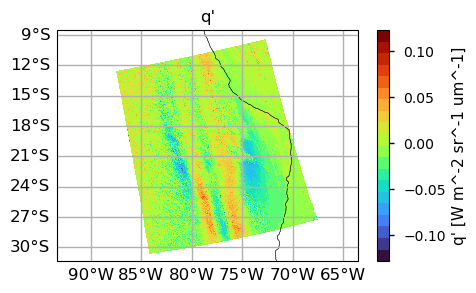

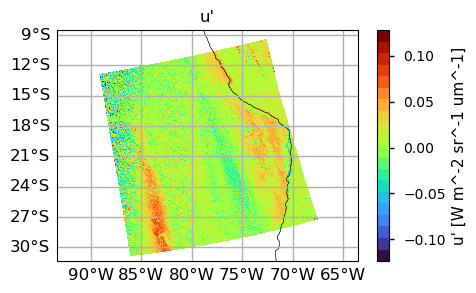

In [23]:
## PROCEED TO L1C
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
#temp = np.sqrt(L1C_dataset[var].values[:,:,10:70]**2+L1C_dataset["u"].values[:,:,10:70]**2) 
Q=(np.pi*L1C_dataset["q"])/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"])))
U=(np.pi*L1C_dataset["u"])/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"])))
rot=np.deg2rad(L1C_dataset["rotation_angle"])
_arr = Q * np.cos(2*rot) - U * np.sin(2*rot)

iang=45
_arr=_arr.values[:,:,iang].squeeze()
arr2 = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr2.compressed()[extremes_removed_ids(arr2.compressed())].min(),
    arr2.compressed()[extremes_removed_ids(arr2.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L1C_dataset.longitude,
    L1C_dataset.latitude,
    arr2,
    transform=transform,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title("q'", size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % ("q'", L1C_dataset["q"].units)
)

## PROCEED TO L1C
fig1, ax1 = plt.subplots(figsize=(5, 3), subplot_kw={"projection": projection})
cmap = plt.get_cmap("turbo", 20)
_arr = Q * np.sin(2*rot) + U * np.cos(2*rot)

iang=55
_arr=_arr.values[:,:,iang].squeeze()

arr2 = np.ma.masked_array(_arr, mask=np.isnan(_arr))
# vmin, vmax = har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_min'), har_l2_tes.read_from_file('retrievals/%s'%variable_list[i],attrs_local='valid_max')
vmin, vmax = (
    arr2.compressed()[extremes_removed_ids(arr2.compressed())].min(),
    arr2.compressed()[extremes_removed_ids(arr2.compressed())].max(),
)
ctf = ax1.pcolormesh(
    L1C_dataset.longitude,
    L1C_dataset.latitude,
    arr2,
    transform=transform,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title("u'", size=12)
gl = geo_axis_tags(ax1, crs=transform)
# plt.colorbar(pm, ax=ax_map, orientation="vertical", pad=0.1, label=label)
fig1.colorbar(
    ctf, ax=ax1, orientation="vertical", label="%s [%s]" % ("u'", L1C_dataset["u"].units)
)

In [24]:


band_order=L1B_dataset["intensity_wavelength"].to_numpy()
view_order=L1B_dataset["sensor_view_angle"].to_numpy()
#L1B_dataset["rotation_angle"]
#L1B_dataset["sensor_viewing_angle"]
print(band_order)

[549.465 549.465 549.465 549.465 549.465 549.465 549.465 549.465 549.465
 549.465 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564
 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564
 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564
 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564
 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564
 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564 664.564
 664.564 664.564 664.564 664.564 664.564 664.564 664.564 865.283 865.283
 865.283 865.283 865.283 865.283 865.283 865.283 865.283 865.283 440.159
 440.159 440.159 440.159 440.159 440.159 440.159 440.159 440.159 440.159]


In [25]:
def rad_to_refl(rad, f0, sza, r):
    """Convert radiance to reflectance.

    :param rad: radiance
    :param f0: solar irradiance
    :param sza: solar zenith angle
    :param r: Sun-Earth distance (in AU)

    :returns: reflectance
    """
    return (r**2) * np.pi * rad / np.cos(sza * np.pi / 180) / f0

In [26]:
L1C_dataset["solar_zenith_angle"].shape

(395, 519, 90)

In [27]:

scat=L1C_dataset["scattering_angle"][:,:,10:70].squeeze()
vza=L1C_dataset["sensor_zenith_angle"][:,:,10:70].squeeze()
sza=L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze()


I = rad_to_refl(
    rad=L1C_dataset["i"][:,:,10:70].squeeze(),
    f0=L1C_dataset["intensity_f0"][10:70],
    sza=L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze(),
    r=float(L1C_dataset.attrs["sun_earth_distance"]),
).squeeze()
Q = rad_to_refl(
    rad=L1C_dataset["q"][:,:,10:70].squeeze(),
    f0=L1C_dataset["intensity_f0"][10:70],
    sza=L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze(),
    r=float(L1C_dataset.attrs["sun_earth_distance"]),
).squeeze()
U = rad_to_refl(
    rad=L1C_dataset["u"][:,:,10:70].squeeze(),
    f0=L1C_dataset["intensity_f0"][10:70],
    sza=L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze(),
    r=float(L1C_dataset.attrs["sun_earth_distance"]),
).squeeze()


#I = (np.pi*L1C_dataset["i"][:,:,10:70].squeeze())/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze())))
#Q = (np.pi*L1C_dataset["q"][:,:,10:70].squeeze())/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze())))
#U = (np.pi*L1C_dataset["u"][:,:,10:70].squeeze())/(1531.9*np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze())))
Ip = np.sqrt(Q**2+U**2)
rot = np.deg2rad(L1C_dataset["rotation_angle"][:,:,10:70]).squeeze()
rot_plt = L1C_dataset["rotation_angle"][:,:,10:70].squeeze()
# Old version of L1C doc
Qp = Q * np.cos(2*rot) - U * np.sin(2*rot)
Up = Q * np.sin(2*rot) + U * np.cos(2*rot)
# New version of L1C doc
Qp = Q * np.cos(2*rot) + U * np.sin(2*rot)
Up = - Q * np.sin(2*rot) + U * np.cos(2*rot)
Ip = np.sqrt(Qp**2+Up**2)

Ip2=np.sqrt(Q**2+U**2)
Qp2= L1C_dataset["q"][:,:,10:70].squeeze() * np.cos(2*rot) - L1C_dataset["u"][:,:,10:70].squeeze() * np.sin(2*rot)
Up2= L1C_dataset["q"][:,:,10:70].squeeze() * np.sin(2*rot) + L1C_dataset["u"][:,:,10:70].squeeze() * np.cos(2*rot)
Q2 = (-4*Qp2)*(1+np.cos(np.deg2rad(L1C_dataset["sensor_zenith_angle"][:,:,10:70].squeeze()))/np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze())))
U2 = (-4*Up2)*(1+np.cos(np.deg2rad(L1C_dataset["sensor_zenith_angle"][:,:,10:70].squeeze()))/np.cos(np.deg2rad(L1C_dataset["solar_zenith_angle"][:,:,10:70].squeeze())))


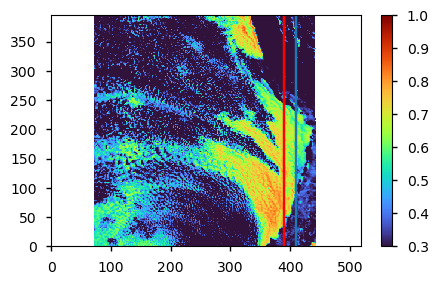

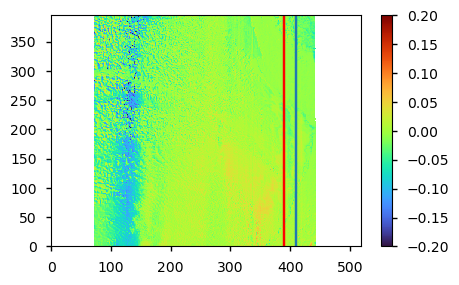

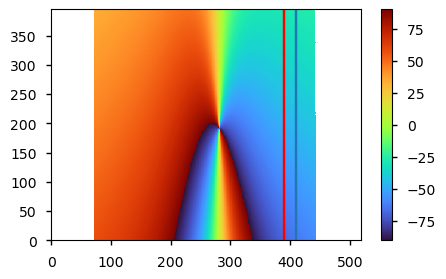

(395, 519, 60)

In [28]:
# Confirm index to explore

iang=48

fig, ax = plt.subplots(figsize=(5, 3))
im1=ax.pcolormesh(I[:,:,iang], cmap="turbo",vmin=0.3,vmax=1)
plt.axvline(410)
plt.axvline(390,color='red')
fig.colorbar(im1, ax=ax, orientation='vertical')
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
im1=ax.pcolormesh(Qp[:,:,iang], cmap="turbo",vmin=-0.2,vmax=0.2)
plt.axvline(410)
plt.axvline(390,color='red')
fig.colorbar(im1, ax=ax, orientation='vertical')
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
im1=ax.pcolormesh(rot_plt[:,:,iang], cmap="turbo")
plt.axvline(410)
plt.axvline(390,color='red')
fig.colorbar(im1, ax=ax, orientation='vertical')
plt.show()

Qp.shape
rot.shape

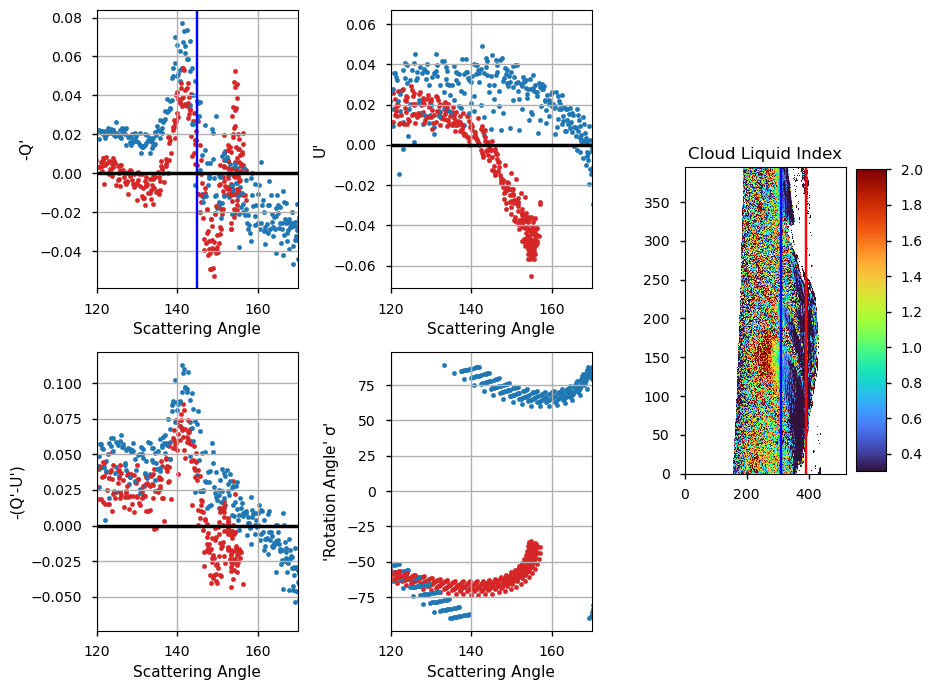

In [47]:
fig = plt.figure(figsize=(12, 7)) # Adjust figsize as needed
gs = fig.add_gridspec(2, 4)

# Create the 2x2 matrix of plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Create the single side plot spanning both rows of the third column
ax_side = fig.add_subplot(gs[:, 2:3]) # gs[:, 2] spans all rows of the 3rd column



iy1=310
iy2=390
iang=48

#iy1=100
#iy2=190
#iang=48

for ix in range(0,394,10):
    if (I[ix,iy1,:].min()>0.2) & (I[ix,iy2,:].min()>0.2):
        diffmap1=np.diff(scat[ix,iy1,:], prepend=0)
        diffmap2=np.diff(scat[ix,iy2,:], prepend=0)
        ax1.scatter(scat[ix,iy1,:].where(diffmap1>0), -Qp[ix,iy1,:].where(diffmap1>0), s=10, color="tab:blue",label='left')    # First panel
        ax1.scatter(scat[ix,iy2,:].where(diffmap2>0), -Qp[ix,iy2,:].where(diffmap2>0), s=10, color="tab:red",label='right')    # First panel
        ax2.scatter(scat[ix,iy1,:].where(diffmap1>0), Up[ix,iy1,:].where(diffmap1>0), s=10, color="tab:blue",label='left')    # First panel
        ax2.scatter(scat[ix,iy2,:].where(diffmap2>0), Up[ix,iy2,:].where(diffmap2>0), s=10, color="tab:red",label='right')    # First panel
        ax3.scatter(scat[ix,iy1,:].where(diffmap1>0), -(Qp[ix,iy1,:].where(diffmap1>0)-Up[ix,iy1,:].where(diffmap1>0)), s=10, color="tab:blue",label='left')    # First panel
        ax3.scatter(scat[ix,iy2,:].where(diffmap2>0), -(Qp[ix,iy2,:].where(diffmap2>0)-Up[ix,iy1,:].where(diffmap1>0)), s=10, color="tab:red",label='right')    # First panel
        ax4.scatter(scat[ix,iy1,:].where(diffmap1>0), rot_plt[ix,iy1,:].where(diffmap1>0), s=10, color="tab:blue",label='left')    # First panel
        ax4.scatter(scat[ix,iy2,:].where(diffmap2>0), rot_plt[ix,iy2,:].where(diffmap2>0), s=10, color="tab:red",label='right')    # First panel
    else:
        continue
        
ax1.set_ylabel("-Q'")
ax1.set_xlabel("Scattering Angle")
ax1.grid(True)
ax1.set_xlim(120, 170)
ax1.axvline(145,color='blue')
ax1.axhline(linewidth=2.5, color='black')

ax2.set_ylabel("U'")
ax2.set_xlabel("Scattering Angle")
#ax1.legend()
ax2.grid(True)
ax2.set_xlim(120, 170)
ax2.axhline(linewidth=2.5, color='black')

ax3.set_xlabel("Scattering Angle")
ax3.set_ylabel("-(Q'-U')")
#ax1.legend()
ax3.grid(True)
ax3.set_xlim(120, 170)
ax3.axhline(linewidth=2.5, color='black')

ax4.set_xlabel("Scattering Angle")
ax4.set_ylabel("'Rotation Angle' $\mathrm{\sigma}$'")
ax4.grid(True)
ax4.set_xlim(120, 170)

ax_side.set_title('Cloud Liquid Index')
ax_side.set_aspect(2.5) 
im1=ax_side.pcolormesh(L2_dataset["cloud_liquid_index"].values, cmap="turbo",vmin=0.3,vmax=2)
plt.axvline(iy1,color='blue')
plt.axvline(iy2,color='red')
fig.colorbar(im1, ax=ax_side, orientation='vertical', shrink=1, aspect=10)
plt.tight_layout()
plt.show()

Liquid Index as defined in: https://www.giss.nasa.gov/pubs/docs/2012/2012_VanDiedenhoven_va04100j.pdf



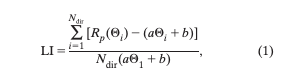

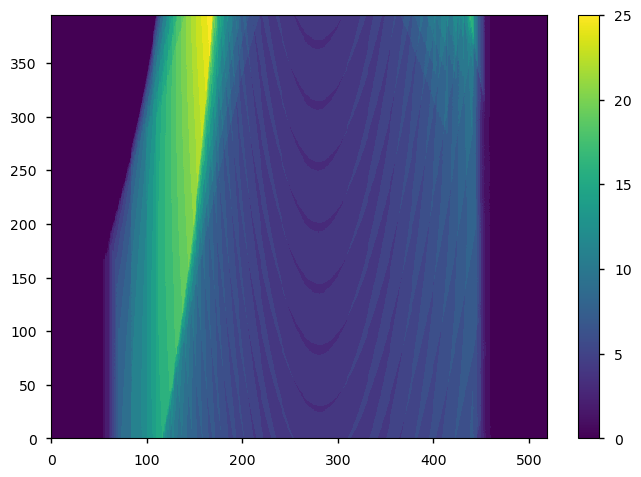

<bound method DataArrayAggregations.count of <xarray.DataArray 'scattering_angle' (number_of_views: 60)> Size: 60B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])
Dimensions without coordinates: number_of_views>

In [78]:
scat.shape
scat.dims
count_bow.shape
plt.pcolormesh(count_bow)
plt.colorbar()
plt.show()
mask_bow[200,200,:].count

In [1]:
#scat_samp=scat.where((scat>120 & scat<130) | (scat>120 & scat<130))
mask_out = ((scat >= 120) & (scat <= 130)) | ((scat >= 150) & (scat <= 160))
mask_bow = ((scat >= 135) & (scat <= 145))
#count_bow = mask_bow.count(dim=["number_of_views"])
count_bow = scat.where(mask_bow).count(dim=["number_of_views"])
scat_out=scat.where(mask_out)
Q_out = Qp.where(mask_out)
U_out = Up.where(mask_out)

scat_bow=scat.where(mask_bow)
Q_bow = Qp.where(mask_bow)
U_bow = Up.where(mask_bow)

fig = plt.figure(figsize=(5,9)) # Adjust figsize as needed
gs = fig.add_gridspec(3, 1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

iy1=310

ax1.scatter(scat_out[range(0,394,5),iy1,:], -Q_out[range(0,394,5),iy1,:], s=10, color="tab:blue")    # First panel
ax1.scatter(scat_bow[range(0,394,5),iy1,:], -Q_bow[range(0,394,5),iy1,:], s=10, color="tab:red")    # First panel
ax2.scatter(scat_out[range(0,394,5),iy1,:], np.sqrt(Q_out[range(0,394,5),iy1,:]**2+U_out[range(0,394,5),iy1,:]**2), s=10, color="tab:blue")    # First panel
ax2.scatter(scat_bow[range(0,394,5),iy1,:], np.sqrt(Q_bow[range(0,394,5),iy1,:]**2+U_bow[range(0,394,5),iy1,:]**2), s=10, color="tab:red")    # First panel
ax3.scatter(scat_out[range(0,394,5),iy1,:],-(Q_out[range(0,394,5),iy1,:]-U_out[range(0,394,5),iy1,:]), s=10, color="tab:blue")    # First panel
ax3.scatter(scat_bow[range(0,394,5),iy1,:], -(Q_bow[range(0,394,5),iy1,:]-U_bow[range(0,394,5),iy1,:]), s=10, color="tab:red")    # First panel
   
   

#model = LinearRegression()


NameError: name 'scat' is not defined

In [ ]:
scat_samp=scat(scat>120 & scat<130) | (scat>120 & scat<130))
Ndir=countbow
scat1=135
a=
b=
LI=(-Qp-a*scat_samp+b)/(Nang(a*scat_1+b))